<a href="https://colab.research.google.com/github/lunecarvalho/newslens-project/blob/main/05_training_testing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("dataset_preprocessado.csv")

In [5]:
df.shape

(7199, 11)

In [6]:
df.columns.tolist()

['id',
 'label',
 'arquivo',
 'texto_original',
 'texto_preprocessado',
 'topico_bertopic',
 'tema',
 'tamanho_caracteres',
 'tamanho_palavras',
 'texto_preprocessado_sem_acento',
 'texto_lematizado']

In [7]:
df["label"].value_counts()

,count
label,
falso,3600
verdadeiro,3599


Primeiro treinamento:

In [8]:
X = df["texto_preprocessado_sem_acento"].fillna("")
y = df["label"]

In [9]:
y = y.map({
    "falso": 0,
    "verdadeiro": 1
})

Reserva 20% dos dados para teste:

In [10]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_treino_tfidf = vectorizer.fit_transform(X_treino)
X_teste_tfidf = vectorizer.transform(X_teste)

In [12]:
print("Treino:", X_treino_tfidf.shape)
print("Teste:", X_teste_tfidf.shape)
print("Quantidade de termos:", len(vectorizer.get_feature_names_out()))

Treino: (5759, 113335)
Teste: (1440, 113335)
Quantidade de termos: 113335


### Regressão Logística:

In [13]:
from sklearn.linear_model import LogisticRegression

modelo_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_baseline.fit(
    X_treino_tfidf,
    y_treino
)

LogisticRegression(max_iter=1000, random_state=42)

In [14]:
y_pred = modelo_baseline.predict(X_teste_tfidf)

y_prob = modelo_baseline.predict_proba(X_teste_tfidf)[:, 1]

Avaliação do modelo:

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_teste, y_pred))
print("Precision:", precision_score(y_teste, y_pred))
print("Recall:", recall_score(y_teste, y_pred))
print("F1-score:", f1_score(y_teste, y_pred))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=["Falsa", "Verdadeira"]
    )
)

Accuracy: 0.90625
Precision: 0.9068150208623088
Recall: 0.9055555555555556
F1-score: 0.906184850590688

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.91      0.91      0.91       720
  Verdadeira       0.91      0.91      0.91       720

    accuracy                           0.91      1440
   macro avg       0.91      0.91      0.91      1440
weighted avg       0.91      0.91      0.91      1440



Resultado inicial:

| Métrica       |  Resultado |
| ------------- | ---------: |
| **Accuracy**  | **90,63%** |
| **Precision** | **90,68%** |
| **Recall**    | **90,56%** |
| **F1-score**  | **90,62%** |


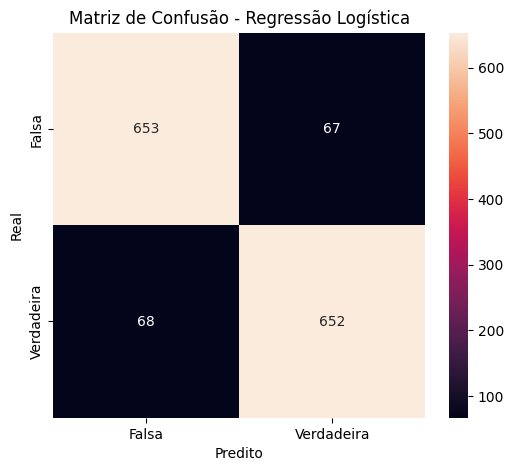

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

matriz = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    xticklabels=["Falsa", "Verdadeira"],
    yticklabels=["Falsa", "Verdadeira"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Regressão Logística")

plt.show()

Isso significa:

* **653 falsas** foram identificadas corretamente.
* **652 verdadeiras** foram identificadas corretamente.
* **67 falsas** foram classificadas como verdadeiras.
* **68 verdadeiras** foram classificadas como falsas.

Ou seja, o modelo errou 135 de 1.440 notícias.

### Treinamento Linear SVM:

In [17]:
from sklearn.svm import LinearSVC

modelo_svm = LinearSVC(
    random_state=42
)

modelo_svm.fit(
    X_treino_tfidf,
    y_treino
)

LinearSVC(random_state=42)

In [18]:
y_pred_svm = modelo_svm.predict(X_teste_tfidf)

In [19]:
print("Accuracy:", accuracy_score(y_teste, y_pred_svm))
print("Precision:", precision_score(y_teste, y_pred_svm))
print("Recall:", recall_score(y_teste, y_pred_svm))
print("F1-score:", f1_score(y_teste, y_pred_svm))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred_svm,
        target_names=["Falsa", "Verdadeira"]
    )
)

Accuracy: 0.9347222222222222
Precision: 0.929945054945055
Recall: 0.9402777777777778
F1-score: 0.9350828729281768

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.94      0.93      0.93       720
  Verdadeira       0.93      0.94      0.94       720

    accuracy                           0.93      1440
   macro avg       0.93      0.93      0.93      1440
weighted avg       0.93      0.93      0.93      1440



Usando o Linear SVM, o ganho de *Accuracy* foi de aproximadamente 2,84 pontos percentuais, e o *F1* aumentou de **90,62%** para **93,51%**.

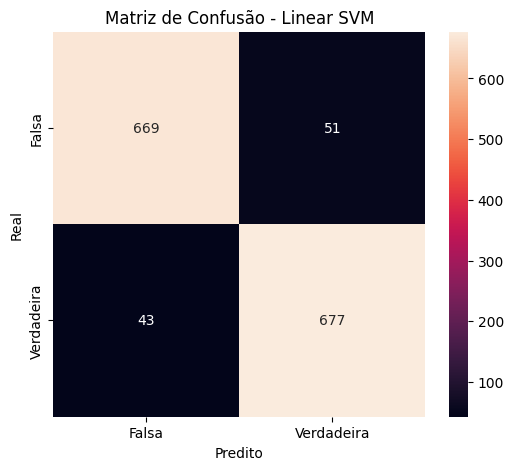

In [20]:
matriz_svm = confusion_matrix(y_teste, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_svm,
    annot=True,
    fmt="d",
    xticklabels=["Falsa", "Verdadeira"],
    yticklabels=["Falsa", "Verdadeira"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Linear SVM")

plt.show()

Dos 1.440 textos de teste:

* **669 falsas** → corretamente
identificadas como falsas.
* **677 verdadeiras** → corretamente identificadas como verdadeiras.
* **51 falsas** → classificadas incorretamente como verdadeiras.
* **43 verdadeiras** → classificadas incorretamente como falsas.

Isso dá **1.346** acertos de **1.440**, ou **93,47%.**

### Naive Bayes:

In [21]:
from sklearn.naive_bayes import MultinomialNB

modelo_nb = MultinomialNB()

modelo_nb.fit(
    X_treino_tfidf,
    y_treino
)

MultinomialNB()

In [22]:
y_pred_nb = modelo_nb.predict(X_teste_tfidf)

In [23]:
print("Accuracy:", accuracy_score(y_teste, y_pred_nb))
print("Precision:", precision_score(y_teste, y_pred_nb))
print("Recall:", recall_score(y_teste, y_pred_nb))
print("F1-score:", f1_score(y_teste, y_pred_nb))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred_nb,
        target_names=["Falsa", "Verdadeira"]
    )
)

Accuracy: 0.8694444444444445
Precision: 0.8565683646112601
Recall: 0.8875
F1-score: 0.8717598908594816

Relatório de classificação:
              precision    recall  f1-score   support

       Falsa       0.88      0.85      0.87       720
  Verdadeira       0.86      0.89      0.87       720

    accuracy                           0.87      1440
   macro avg       0.87      0.87      0.87      1440
weighted avg       0.87      0.87      0.87      1440



*Naive Bayes* mostra **desempenho** **inferior** comparado a *Regressão Logística* e *Linear SVM*.

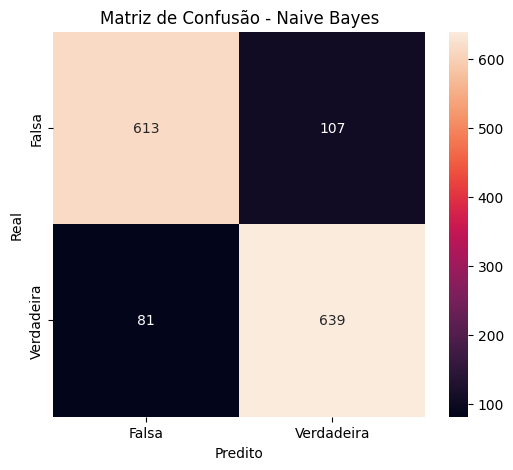

In [24]:
matriz_nb = confusion_matrix(y_teste, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_nb,
    annot=True,
    fmt="d",
    xticklabels=["Falsa", "Verdadeira"],
    yticklabels=["Falsa", "Verdadeira"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Naive Bayes")

plt.show()

#### Comparação dos três modelos:

| Modelo              |   Accuracy |  Precision |     Recall |   F1-score |
| ------------------- | ---------: | ---------: | ---------: | ---------: |
| Regressão Logística |     90,63% |     90,68% |     90,56% |     90,62% |
| **Linear SVM**      | **93,47%** | **92,99%** | **94,03%** | **93,51%** |
| Naive Bayes         |     86,94% |     85,66% |     88,75% |     87,18% |

Para a representação textual atual baseada em **TF-IDF com unigramas + bigramas**, o *Linear SVM* foi o modelo que melhor conseguiu separar notícias falsas e verdadeiras.

In [25]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_teste, y_pred),
        accuracy_score(y_teste, y_pred_svm),
        accuracy_score(y_teste, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_teste, y_pred),
        precision_score(y_teste, y_pred_svm),
        precision_score(y_teste, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_teste, y_pred),
        recall_score(y_teste, y_pred_svm),
        recall_score(y_teste, y_pred_nb)
    ],
    "F1-score": [
        f1_score(y_teste, y_pred),
        f1_score(y_teste, y_pred_svm),
        f1_score(y_teste, y_pred_nb)
    ]
})

resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regressão Logística,0.906250,0.906815,0.905556,0.906185
1,Linear SVM,0.934722,0.929945,0.940278,0.935083
2,Naive Bayes,0.869444,0.856568,0.887500,0.871760
